In [1]:
import os
# from dotenv import load_dotenv
import sqlite3
import uuid
import re
import json
import operator
import torch
import json_repair
from datetime import datetime
from typing import Annotated, TypedDict, List, Dict, Optional, Literal

from huggingface_hub import login
from transformers import pipeline, BitsAndBytesConfig
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display




/home/abhishek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

HF_TOKEN = os.getenv('HF_TOKEN')
if HF_TOKEN:
    login(token=HF_TOKEN)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:

# load_dotenv()  
# # Force enable LangSmith tracing for this session
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "MedGemma-RouterAgent"

In [4]:
class RouterState(TypedDict):
    # Inputs
    patient_id: str

    # Processed Data
    clinical_history: Dict  # Raw data from EHR
    recent_symptoms: List[Dict]
    clinical_summary: str

    ## Available Facilites
    available_departments: List[str]
    available_imaging: List[str]
    available_labs: List[str]

    # AI Outputs
    triage_priority: str   # "EMERGENT", "URGENT", "STABLE"
    selected_departments: List[str]

    recommended_imaging: List[Dict]
    recommended_labs: List[Dict]
    encounter_class: str


    # Logistics
    available_slots: List[Dict]
    booking_status: str    # "pending", "confirmed", "manual_review"

    # Control flow
    needs_manual_review: bool
    error_log: Annotated[list, operator.add]

    # Audit & HIL
    routing_notes: Annotated[list, operator.add]

# class ClinicalOrder(BaseModel):
#     name: str = "Unknown"
#     priority: Literal["STAT", "ROUTINE"] = "ROUTINE"
#     reason: str = "Clinically indicated based on symptoms"
#     confidence: float = Field(default=0.5, ge=0.0, le=1.0)

# class TriageOutput(BaseModel):
#     triage_priority: Literal["EMERGENT", "URGENT", "STABLE"]
#     departments: List[str]
#     # Pydantic handles the nesting here:
#     recommended_imaging: List[ClinicalOrder] = Field(default_factory=list)
#     recommended_labs: List[ClinicalOrder] = Field(default_factory=list)
#     clinical_summary: str
#     encounter_class: Optional[str] = "ambulatory"


In [5]:
### Issues and TODOs:
## 1) Consistency in db: Speciality in doctor and Department in medgemma triage for availability check and booking ==> standardize this to avoid confusion.
## 2) Imaging and Lab tests: Currently, we are only routing to departments. We should also consider if the patient needs to be routed for specific imaging or lab tests based on their symptoms and history.


In [6]:
class EHRService:
    def __init__(self, db_path='/home/abhishek/Projects/Continuum/data/ehr.db'):
        self.db_path = db_path
        if not os.path.exists(self.db_path):
            raise FileNotFoundError(f"Database not found at {os.path.abspath(db_path)}")

    def get_patient_context(self, patient_id):
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            query = """
                SELECT p.first_name, p.last_name, mh.condition_name, mh.status
                FROM patients p
                LEFT JOIN medical_history mh ON p.patient_id = mh.patient_id
                WHERE p.patient_id = ?
            """
            cursor.execute(query, (patient_id,))
            rows = cursor.fetchall()
            if not rows: return None
            # Formatting for the Agent's prompt
            history = [f"{r[2]} ({r[3]})" for r in rows if r[2]]
            return f"Patient: {rows[0][0]} {rows[0][1]}. History: {', '.join(history)}"

    def get_recent_symptoms(self, patient_id):
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            query = """
                SELECT s.name, es.severity 
                FROM encounters e
                JOIN encounter_symptoms es ON e.encounter_id = es.encounter_id
                JOIN symptoms s ON es.symptom_id = s.symptom_id
                WHERE e.patient_id = ? ORDER BY e.encounter_date DESC LIMIT 3
            """
            cursor.execute(query, (patient_id,))
            return [{"symptom": r[0], "severity": r[1]} for r in cursor.fetchall()]


class SchedulingService:
    def __init__(self, db_path='/home/abhishek/Projects/Continuum/data/his.db'):
        self.db_path = db_path
        if not os.path.exists(self.db_path):
            raise FileNotFoundError(f"Database not found at {os.path.abspath(db_path)}")

    def get_all_departments(self):
        """Fetches all registered department names for the Router Agent."""
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            query = "SELECT name FROM departments"
            cursor.execute(query)
            # Fetchall returns a list of tuples like [('Cardiology',), ('Pediatrics',)]
            # We convert it to ['Cardiology', 'Pediatrics']
            return [row[0] for row in cursor.fetchall()]


    def get_all_imaging_tests(self):
        # """Fetches all registered imaging test names for the Router Agent."""
        # with sqlite3.connect(self.db_path) as conn:
        #     cursor = conn.cursor()
        #     query = "SELECT name FROM imaging_tests"
        #     cursor.execute(query)
        #     return [row[0] for row in cursor.fetchall()]
        return ["X-Ray", "MRI", "CT Scan", "Ultrasound"]  # Placeholder for testing
    
    def get_all_lab_tests(self):
        # """Fetches all registered lab test names for the Router Agent."""
        # with sqlite3.connect(self.db_path) as conn:
        #     cursor = conn.cursor()
        #     query = "SELECT name FROM lab_tests"
        #     cursor.execute(query)
        #     return [row[0] for row in cursor.fetchall()]
        return ["CBC", "Lipid Panel", "Blood Glucose", "Liver Function"]  # Placeholder for testing

    

    def get_free_slots(self, specialty):
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            # Logic: Find doctors with this specialty who have unbooked slots
            query = """
                SELECT da.slot_id, d.name, da.available_date, da.start_time, d.doctor_id
                FROM doctor_availability da
                JOIN doctors d ON da.doctor_id = d.doctor_id
                WHERE d.specialty = ? AND da.is_booked = 0
            """
            cursor.execute(query, (specialty,))
            # Returning doctor_id as well, as it is required for the appointments table
            return [{
                "slot_id": r[0], 
                "doctor_name": r[1], 
                "time": f"{r[2]} {r[3]}",
                "doctor_id": r[4]
            } for r in cursor.fetchall()]

    def confirm_booking(self, patient_id, slot):
        """
        Expects 'slot' dictionary containing 'slot_id' and 'doctor_id'
        """
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()

            # Check if still available
            # cursor.execute("SELECT is_booked FROM doctor_availability WHERE slot_id = ?", (slot['slot_id'],))
            # if cursor.fetchone()[0] == 1:
            #     raise Exception("Slot was taken while waiting for approval!")
            
            # 1. Mark slot as booked in doctor_availability
            cursor.execute("""
                UPDATE doctor_availability 
                SET is_booked = 1 
                WHERE slot_id = ?
            """, (slot['slot_id'],))
            
            # 2. Create the appointment record 
            # Note: appt_id is the PK in your new schema
            appt_id = f"APT-{str(uuid.uuid4())[:8]}"
            
            cursor.execute("""
                INSERT INTO appointments (appt_id, patient_id, doctor_id, slot_id, status) 
                VALUES (?, ?, ?, ?, ?)
            """, (appt_id, patient_id, slot['doctor_id'], slot['slot_id'], 'Scheduled'))
            
            conn.commit()
            return appt_id

In [7]:
### Helper Functions:
def extract_first_json(text: str):
    """Finds the first '{' and last '}' in a string and returns the content between."""
    try:
        start_idx = text.find('{')
        end_idx = text.rfind('}')
        if start_idx == -1 or end_idx == -1:
            return None
        return text[start_idx:end_idx + 1]
    except Exception:
        return None


def extract_valid_triage_dict(data):
    """
    Given a list of dictionaries from the LLM, finds the one 
    that contains actual clinical data rather than placeholders.
    """
    if isinstance(data, dict):
        return data
    
    if isinstance(data, list):
        for item in reversed(data):  # Usually the last JSON block is the final answer
            if not isinstance(item, dict):
                continue
                
            # Check if this is the 'real' one by looking for non-placeholder priority
            priority = item.get("triage_priority", "")
            if priority and "|" not in priority and "<" not in priority:
                return item
                
        # Fallback: if we didn't find a 'clean' one, take the last dictionary found
        dicts_only = [i for i in data if isinstance(i, dict)]
        return dicts_only[-1] if dicts_only else None

    return None

In [8]:
class RouterAgent:
    def __init__(self, scheduling_service, ehr_service,triage_pipeline):
        self.scheduler = scheduling_service
        self.ehr = ehr_service
        self.memory = MemorySaver()
        self.triage_pipe=triage_pipeline
        self.workflow = self._build_graph()

    def _build_graph(self):
        graph = StateGraph(RouterState)

        # 1. Ingest Data -> 2. Triage -> 3. Get Slots -> 4. Route

        graph.add_node("ingest_patient_data", self._load_context)
        graph.add_node("medgemma_triage", self._medgemma_triage)
        graph.add_node("fetch_availability", self._fetch_availability)
        graph.add_node("human_review", self._human_review)
        graph.add_node("finalize_booking", self._finalize_booking)

        graph.set_entry_point("ingest_patient_data")
        graph.add_edge("ingest_patient_data", "medgemma_triage")


        graph.add_conditional_edges(
            "medgemma_triage",
            self._check_triage_success,
            {
                "fail": "human_review",
                "success": "fetch_availability"
            }
        )

        # graph.add_edge("medgemma_triage", "fetch_availability")

        graph.add_conditional_edges(
            "fetch_availability",
            self._routing_logic,
            {
                "manual": "human_review",
                "auto":"human_review"
                # "auto": "finalize_booking"
            }
        )

        graph.add_edge("human_review", "finalize_booking")
        graph.add_edge("finalize_booking", END)

        return graph.compile(checkpointer=self.memory, interrupt_before=["finalize_booking"])


    def _load_context(self, state: RouterState):
        pid = state["patient_id"]
        # Fetching from your EHR service
        history = self.ehr.get_patient_context(pid) or {}
        symptoms = self.ehr.get_recent_symptoms(pid) or []
        depts = self.scheduler.get_all_departments()
        imaging=self.scheduler.get_all_imaging_tests()
        labs=self.scheduler.get_all_lab_tests()


        return {
            "clinical_history": history,
            "recent_symptoms": symptoms,
            "available_departments": depts,
            "available_imaging_tests": imaging,
            "available_lab_tests": labs,
            "routing_notes": ["Data ingested from EHR."]
        }



    def _medgemma_triage(self, state: RouterState):
        # 1. Prepare context strings
        valid_depts = state.get("available_departments", [])
        dept_options = ", ".join(valid_depts)
        imaging_options = ", ".join(state.get("available_imaging_tests", []))
        lab_options = ", ".join(state.get("available_lab_tests", []))
        symptoms_text = ", ".join([s.get('symptom', 'Unknown') for s in state["recent_symptoms"]])

        # 2. Construct the prompt
        prompt = f"""[SYSTEM]
        You are a clinical triage assistant.

        VALID DEPARTMENTS: {dept_options}
        VALID_IMAGEING_TESTS: {imaging_options}
        VALID_LAB_TESTS: {lab_options}


        Return STRICT JSON only:

        {{
        "triage_priority": "EMERGENT | URGENT | STABLE",
        "recommended_imaging": [
            {{
            "name": "<imaging_test>",
            "priority": "STAT | ROUTINE",
            "reason": "<brief clinical reason>",
            "confidence": 0.0-1.0
            }}
        ],
        "recommended_labs": [
            {{
            "name": "<lab_test>",
            "priority": "STAT | ROUTINE",
            "reason": "<brief clinical reason>",
            "confidence": 0.0-1.0
            }}
        ],
        "departments": ["<department_name>"],
        "clinical_summary": "<short explanation>"
        }}

        [PATIENT DATA]
        Symptoms: {symptoms_text}
        History: {state.get('clinical_history', 'N/A')}
        """


        try:
            # 3. Generate and Repair JSON
            raw_output = self.triage_pipe(prompt, max_new_tokens=500)[0]['generated_text']
            json_string = extract_first_json(raw_output)

            # json_repair is great because it fixes trailing commas or missing quotes
            data = json_repair.loads(json_string)
            # print(data,flush=True)

            if isinstance(data, list):
                data = data[-1]
            print(json.dumps(data, indent=4))


            # 4. Extract and Fallback Logic
            # Filter departments to ensure they match your valid list
            raw_depts = data.get("departments", [])
            clean_depts = [d for d in raw_depts if d in valid_depts]
            if not clean_depts:
                clean_depts = ["General Practice"]

            return {
                "triage_priority": data.get("triage_priority", "STABLE"),
                "selected_departments": clean_depts,
                "recommended_imaging": data.get("recommended_imaging", []),
                "recommended_lab_tests": data.get("recommended_labs", []),
                "encounter_class": data.get("encounter_class", "ambulatory"),
                "clinical_summary": data.get("clinical_summary", "No summary provided."),
                "needs_manual_review": False,
                "routing_notes": ["MedGemma processed successfully"]
            }

        except Exception as e:
            return {
                "needs_manual_review": True,
                "selected_departments": [],
                "recommended_imaging": [],
                "recommended_lab_tests": [],
                "triage_priority": "UNDEFINED",
                "error_log": [f"Parsing error: {str(e)}"],
                "routing_notes": ["CRITICAL: AI parsing failed. Sent to Human Review."]
            }

    def _check_triage_success(self, state: RouterState):
        """Routes to human if AI failed or flag is set."""
        if state.get("needs_manual_review"):
            return "fail"
        return "success"

    def _fetch_availability(self, state: RouterState):
        all_slots = []

        for dept in state.get("selected_departments", []):
            slots = self.scheduler.get_free_slots(dept)
            for slot in slots:
                slot["department"] = dept
            all_slots.extend(slots)

        return {"available_slots": all_slots}


    def _routing_logic(self, state: RouterState):
        """Condition logic to decide the path."""
        if state["triage_priority"] == "EMERGENT" or not state["available_slots"]:
            return "manual"
        return "auto"



    def _human_review(self, state: RouterState):
        # Get current date for the test notes
        current_time = datetime.now().strftime("%Y-%m-%d %H:%M")

        # We include slot_id and doctor_id so confirm_booking doesn't crash
        # Using IDs from your list (e.g., Slot 11, Doctor 11)
        chosen_slots = [{
            "slot_id": 11,
            "doctor_id": 11,
            "doctor_name": "Dr. Test (Manual)",
            "time": f"{current_time}",
            "department": "General Medicine"
        }]

        return {
            "available_slots": chosen_slots,
            "booking_status": "human_approved",
            "routing_notes": [f"Human override triggered at {current_time}. Forced Slot 11."]
        }


    def _finalize_booking(self, state: RouterState):
      available_slots = state.get("available_slots", [])

      if not available_slots:
          return {
              "booking_status": "failed_no_slots",
              "routing_notes": ["Booking failed: No slots were found in state."]
          }

      # Logic to confirm the booking
      self.scheduler.confirm_booking(state["patient_id"], available_slots[0])
      return {
          "booking_status": "confirmed",
          "routing_notes": ["Booking finalized."]
      }


    # def _finalize_booking(self, state: RouterState):
    #     slot = state.get("available_slots")[0] if state.get("available_slots") else None
    #     tech_id = state.get("technician_id")

    #     # Combine labs and imaging into a single 'orders' list for the service
    #     imaging = [{"type": "IMAGING", **i} for i in state.get("recommended_imaging", [])]
    #     labs = [{"type": "LAB", **l} for l in state.get("recommended_lab_tests", [])]
    #     all_orders = imaging + labs

    #     if not slot or not tech_id:
    #         return {"booking_status": "failed_missing_approval"}

    #     # Execute the database transaction
    #     appt_id = self.scheduler.finalize_confirmed_order(
    #         patient_id=state["patient_id"],
    #         slot=slot,
    #         orders=all_orders,
    #         technician_id=tech_id
    #     )

    #     return {
    #         "booking_status": "confirmed",
    #         "final_appointment_id": appt_id,
    #         "routing_notes": [f"Appointment {appt_id} booked and orders placed by {tech_id}."]
    #     }


    def _manual_override(self, state: RouterState):
        """Placeholder for the node that the human interacts with."""
        return {"booking_status": "pending_review"}

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 883/883 [00:03<00:00, 245.28it/s, Materializing param=model.vision_tower.vision_model.post_layernorm.weight]                      
Some parameters are on the meta device because they were offloaded to the cpu.


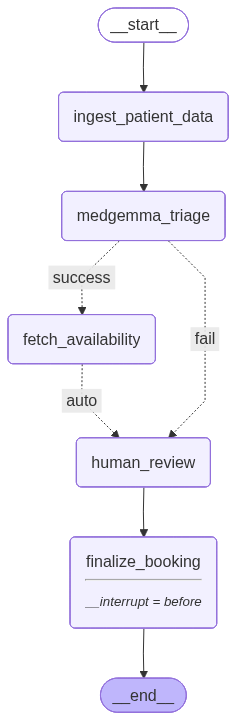

In [9]:
from IPython.display import Image, display
from transformers import BitsAndBytesConfig


# scheduling_service=MockScheduler()
# ehr_service=MockEHR()
scheduling_service=SchedulingService()
ehr_service=EHRService()


# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16
# )

medgemma_pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    # model="google/medgemma-1.5-4b-it",
    # model_kwargs={"quantization_config": quantization_config},
    torch_dtype=torch.bfloat16,
    device_map="auto", # Change to "cuda" if GPU is available
    trust_remote_code=True
)
agent = RouterAgent(scheduling_service,ehr_service,medgemma_pipe)
app = agent.workflow 


display(Image(agent.workflow.get_graph().draw_mermaid_png()))

In [10]:
### Inferene  

In [11]:
# def run_triage_test(patient_id):
#     print(f"\n{'='*50}")
#     print(f">>> STARTING CLINICAL ROUTING TEST: PATIENT {patient_id}")
#     print(f"{'='*50}")

#     config = {"configurable": {"thread_id": f"session_{patient_id}"}}
#     initial_input = {"patient_id": patient_id}

#     print("\n--- PHASE 1: AI Analysis & Triage ---")

#     for event in app.stream(initial_input, config, stream_mode="values"):

#         # Access the keys directly from the event (the state)
#         priority = event.get("triage_priority")
#         depts = event.get("selected_departments") # Note: Plural as per your RouterState
#         status = event.get("booking_status")

#         if priority:
#             print(f"   [MedGemma] Current Priority: {priority}")
#         if depts:
#             print(f"   [MedGemma] Selected Depts: {depts}")
#         if status:
#             print(f"   [Status] {status}")

#     # 2. Check for Interrupt
#     state = app.get_state(config)

#     if state.next:
#         print(f"\n--- PHASE 2: Human-in-the-Loop Interrupt ---")
#         print(f"WAITING: Graph is paused at: {state.next}")

#         # Access values directly from state.values
#         print(f"CURRENT STATE PREVIEW:")
#         print(f"   Priority: {state.values.get('triage_priority')}")
#         print(f"   Departments: {state.values.get('selected_departments')}")

#         print("\n>>> ADMIN: Reviewing notes... Analysis looks correct.")
#         print(">>> ADMIN: Clicking 'Approve Booking'...")

#         # 3. Resume (passing None to continue)
#         for event in app.stream(None, config, stream_mode="values"):
#             final_status = event.get("booking_status")
#             if final_status:
#                 print(f"FINAL RESULT: {final_status}")
#     else:
#         print("\n[FINISH] Graph reached end state without further interaction.")

In [12]:
def print_clinical_dashboard(state_values: dict):
    print(f"\n" + "="*60)
    print(f"CLINICAL REVIEW DASHBOARD")
    print("="*60)
    
    # 1. Patient & Context
    print(f"PATIENT ID: {state_values.get('patient_id')}")
    print(f"PRIORITY:   {state_values.get('triage_priority', 'PENDING')}")
    print(f"DEPARTMENTS: {', '.join(state_values.get('selected_departments', []))}")
    
    # 2. Clinical Summary
    print(f"\nAI SUMMARY:")
    print(f"  {state_values.get('clinical_summary', 'No summary available.')}")
    
    # 3. Orders (Imaging & Labs)
    print(f"\nPROPOSED ORDERS:")
    imaging = state_values.get('recommended_imaging', [])
    labs = state_values.get('recommended_labs', [])
    
    for item in imaging:
        print(f"  [Imaging] {item.get('name')} ({item.get('priority')}) - {item.get('reason')}")
    for item in labs:
        print(f"  [Lab]     {item.get('name')} ({item.get('priority')}) - {item.get('reason')}")
        
    # 4. Available Slots
    print(f"\nAVAILABLE SLOTS:")
    slots = state_values.get('available_slots', [])
    if slots:
        for i, s in enumerate(slots[:3]): # Show top 3
            print(f"  {i+1}. {s.get('time')} with {s.get('doctor_name')} ({s.get('department')})")
    else:
        print("No slots found for the selected departments.")

    # 5. Audit Trail
    print(f"\nROUTING HISTORY:")
    for note in state_values.get('routing_notes', []):
        print(f"  - {note}")
    print("="*60 + "\n")



def run_triage_test(patient_id):
    print(f"\n{'='*50}")
    print(f">>> STARTING CLINICAL ROUTING: PATIENT {patient_id}")
    print(f"{'='*50}")
    
    config = {"configurable": {"thread_id": f"session_{patient_id}"}}
    initial_input = {"patient_id": patient_id}
    
    # 1. Initial AI Processing
    print("\n--- PHASE 1: AI Analysis ---")
    for event in app.stream(initial_input, config, stream_mode="values"):
        # We can extract and print the current state values cleanly
        priority = event.get('triage_priority', 'Pending...')
        dept = event.get('selected_department', 'Pending...')
        print(f"Current Progress -> Priority: {priority} | Dept: {dept}")

    # 2. Human-in-the-Loop Interrupt
    state = app.get_state(config)
    
    # If state.next exists, the graph hit an interrupt (breakpoint)
    if state.next:
        # print(f"\n--- PHASE 2: Human Review Required ---")
        # print(f"The AI suggests: **{state.values.get('triage_priority')}** priority for **{state.values.get('selected_departments')}**.")

        print_clinical_dashboard(state.values)
        
        # USER INPUT SECTION
        user_choice = input("\nAction Required: Type 'y' to approve booking, or 'n' to cancel: ").lower().strip()

        if user_choice == 'y':
            print(">>> User approved. Resuming graph...")
            # 3. Resume the graph by passing None
            for event in app.stream(None, config, stream_mode="values"):
                if "booking_status" in event:
                    print(f"FINAL RESULT: {event['booking_status']}")

        # elif user_choice == 'edit':
        #     new_dept = input("Enter correct department: ")
        #     # Manually update the graph's memory
        #     app.update_state(config, {"selected_department": new_dept})
        #     app.stream(None, config)
        
        else:
            print(">>> User declined. Terminating session.")
    else:
        print("\n[FINISH] Graph completed automatically.")

In [13]:
#
run_triage_test("2cc67927-2601-40d1-aa2a-ee42d58bbe86")


Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



>>> STARTING CLINICAL ROUTING: PATIENT 2cc67927-2601-40d1-aa2a-ee42d58bbe86

--- PHASE 1: AI Analysis ---
Current Progress -> Priority: Pending... | Dept: Pending...
Current Progress -> Priority: Pending... | Dept: Pending...
{
    "triage_priority": "URGENT",
    "recommended_imaging": [
        {
            "name": "Chest X-ray",
            "priority": "STAT",
            "reason": "To rule out pneumonia or other respiratory complications.",
            "confidence": 0.9
        }
    ],
    "recommended_labs": [
        {
            "name": "ABG",
            "priority": "STAT",
            "reason": "To assess oxygenation and ventilation.",
            "confidence": 0.9
        }
    ],
    "departments": [
        "Cardiology",
        "Dermatology",
        "Neurology",
        "Orthopedics",
        "Pediatrics"
    ],
    "clinical_summary": "Anya Sharma presents with wheezing, a history of active asthma, and is exhibiting moderate respiratory distress. Her vital signs show

In [14]:
run_triage_test("P002")

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



>>> STARTING CLINICAL ROUTING: PATIENT P002

--- PHASE 1: AI Analysis ---
Current Progress -> Priority: Pending... | Dept: Pending...
Current Progress -> Priority: Pending... | Dept: Pending...
{
    "triage_priority": "EMERGENT",
    "recommended_imaging": [
        {
            "name": "EKG",
            "priority": "STAT",
            "reason": "ST-segment elevation in leads II, III, and aVF suggests acute inferior wall myocardial infarction.",
            "confidence": 0.95
        },
        {
            "name": "Chest X-ray",
            "priority": "STAT",
            "reason": "Pulmonary edema suggests heart failure.",
            "confidence": 0.9
        },
        {
            "name": "Troponin",
            "priority": "STAT",
            "reason": "Elevated troponin confirms myocardial infarction.",
            "confidence": 0.95
        }
    ],
    "recommended_labs": [
        {
            "name": "BMP",
            "priority": "STAT",
            "reason": "To ass

In [15]:
run_triage_test("75efe7f4-877a-4601-abee-0740b7573331")


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



>>> STARTING CLINICAL ROUTING: PATIENT 75efe7f4-877a-4601-abee-0740b7573331

--- PHASE 1: AI Analysis ---
Current Progress -> Priority: Pending... | Dept: Pending...
Current Progress -> Priority: Pending... | Dept: Pending...
{
    "triage_priority": "STABLE",
    "recommended_imaging": [
        {
            "name": "Routine X-ray of the knee",
            "priority": "ROUTINE",
            "reason": "To assess for joint space narrowing, osteophytes, and other signs of osteoarthritis.",
            "confidence": 0.8
        }
    ],
    "recommended_labs": [
        {
            "name": "Routine CBC",
            "priority": "ROUTINE",
            "reason": "To assess for signs of infection or inflammation.",
            "confidence": 0.6
        }
    ],
    "departments": [
        "Orthopedics"
    ],
    "clinical_summary": "Patient presents with knee pain consistent with osteoarthritis. Routine X-ray and CBC are recommended."
}
Current Progress -> Priority: STABLE | Dept: Pend

In [16]:
run_triage_test("be3eeb0b-50a8-46f1-b389-5f187659d2ce")


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



>>> STARTING CLINICAL ROUTING: PATIENT be3eeb0b-50a8-46f1-b389-5f187659d2ce

--- PHASE 1: AI Analysis ---
Current Progress -> Priority: Pending... | Dept: Pending...
Current Progress -> Priority: Pending... | Dept: Pending...
{
    "triage_priority": "URGENT",
    "recommended_imaging": [
        {
            "name": "EKG",
            "priority": "STAT",
            "reason": "To assess for ST-segment elevation myocardial infarction (STEMI) or other signs of acute coronary syndrome.",
            "confidence": 0.95
        }
    ],
    "recommended_labs": [
        {
            "name": "Cardiac Enzymes (Troponin I)",
            "priority": "STAT",
            "reason": "To rule out myocardial infarction.",
            "confidence": 0.9
        },
        {
            "name": "Complete Blood Count (CBC)",
            "priority": "STAT",
            "reason": "To assess for anemia or infection.",
            "confidence": 0.8
        },
        {
            "name": "Basic Metaboli